In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import NullLocator, NullFormatter

In [177]:
def one_minus_formatter(val, pos):
    if val <= 0:
        return ""
    return f"{1 - val:.3f}" 
def one_minus_formatter_Borg(val, pos):
    if val <= 0:
        return ""
    return f"{1 - val:.3f}" 

## Uniform(0,1) Resource Requirement Distribution

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


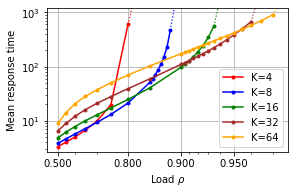

In [178]:
# MRT of non-backfilling MW: Uniform

df = pd.read_excel(
    "/Users/heyuanyao/Desktop/cts MSJ/Simulation Data/Continuous MRJ.xlsx",
    sheet_name="Uniform-MW"
)
Ks = ['4','8','16','32','64']
arrival_rate = df.iloc[:, 0].to_numpy()

fig, ax = plt.subplots(figsize=(6*0.7, 4*0.7))
colors = ['red','blue', 'green', 'brown','orange']
# plt.cm.tab20(np.linspace(0, 1, 5))

x = (2-arrival_rate)/2

y_all = [] 

for i, col in enumerate(df.columns[1:6]):
    y1 = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y1) & (arrival_rate > 0) & (y1 > 0) & (y1 <= 1000) 
    y_valid1 = y1[mask]
    y_all.append(y_valid1)
y_all = np.concatenate(y_all)
y_upLimit = y_all.max()

for i, col in enumerate(df.columns[1:6]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)& (y <= 1000) 
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    ax.plot(
        x_valid,
        y_valid,
        color=colors[i],
        marker='o',
        linewidth=1.5,
        markersize=3,
        # label=col
        label = 'K='+Ks[i]
    )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last * 0.95
    y_fake = y_upLimit * 1.3 

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
    )

ax.set_ylim(y_all.min() * 0.8, y_upLimit * 1.3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()

ax.xaxis.set_major_locator(LogLocator(base=10,subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(FuncFormatter(one_minus_formatter))
ax.xaxis.set_minor_formatter(NullFormatter())


ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel(r"Load $\rho$")
ax.set_ylabel("Mean response time")
ax.tick_params(axis='both')

ax.legend()
ax.grid(True, which="major")

plt.tight_layout()
plt.savefig("uniform-2JEMW-8.eps", format="eps", bbox_inches="tight",dpi=600)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


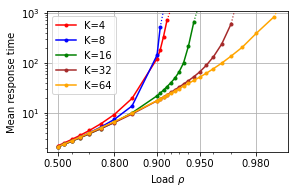

In [179]:
# MRT of Backfilling 2J EMW: Uniform

df = pd.read_excel(
    "/Users/heyuanyao/Desktop/cts MSJ/Simulation Data/Continuous MRJ.xlsx",
    sheet_name="Uniform-MWBack"
)

arrival_rate = df.iloc[:, 0].to_numpy()

fig, ax = plt.subplots(figsize=(6*0.7, 4*0.7))

colors = ['red','blue', 'green', 'brown','orange']


# colors = plt.cm.tab20(np.linspace(0, 1, 5))

x = (2-arrival_rate)/2

y_all = [] 

for i, col in enumerate(df.columns[1:6]):
    y1 = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y1) & (arrival_rate > 0) & (y1 > 0) & (y1 <= 1000) 
    y_valid1 = y1[mask]
    y_all.append(y_valid1)
y_all = np.concatenate(y_all)
y_upLimit = y_all.max()

for i, col in enumerate(df.columns[1:6]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)& (y <= 1000) 
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    ax.plot(
        x_valid,
        y_valid,
        color=colors[i],
        marker='o',
        linewidth=1.5,
        markersize=3,
        # label=col
        label = 'K='+Ks[i]
    )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last * 0.95
    y_fake = y_upLimit * 1.3 

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
    )

ax.set_ylim(y_all.min() * 0.8, y_upLimit * 1.3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()

ax.xaxis.set_major_locator(LogLocator(base=10,subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(FuncFormatter(one_minus_formatter))
ax.xaxis.set_minor_formatter(NullFormatter())


ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel(r"Load $\rho$")
ax.set_ylabel("Mean response time")
ax.tick_params(axis='both')

ax.legend()
ax.grid(True, which="major")

plt.tight_layout()
plt.savefig("uniform-MWBack-8.eps", format="eps", bbox_inches="tight",dpi=600)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


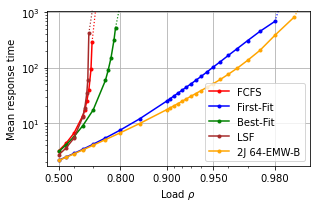

In [180]:
# MRT heuristic v.s. discretization: Uniform

df = pd.read_excel(
    "/Users/heyuanyao/Desktop/cts MSJ/Simulation Data/Continuous MRJ.xlsx",
    sheet_name="Uniform-Comp"
)

arrival_rate = df.iloc[:, 0].to_numpy()

fig, ax = plt.subplots(figsize=(6*0.75, 4*0.75))

# colors = plt.cm.tab20(np.linspace(0, 1, 7))
colors = ['red','blue', 'green', 'brown','orange']

x = (2-arrival_rate)/2

y_all = [] 

for i, col in enumerate(df.columns[1:6]):
    y1 = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y1) & (arrival_rate > 0) & (y1 > 0) & (y1 <= 1000) 
    y_valid1 = y1[mask]
    y_all.append(y_valid1)
y_all = np.concatenate(y_all)
y_upLimit = y_all.max()

for i, col in enumerate(df.columns[1:6]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)& (y <= 1000) 
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    ax.plot(
        x_valid,
        y_valid,
        color=colors[i],
        marker='o',
        linewidth=1.5,
        markersize=3,
        label=col
    )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last * 0.95
    y_fake = y_upLimit * 1.3 

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
    )

ax.set_ylim(y_all.min() * 0.8, y_upLimit * 1.3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()

ax.xaxis.set_major_locator(LogLocator(base=10,subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(FuncFormatter(one_minus_formatter))
ax.xaxis.set_minor_formatter(NullFormatter())


ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel(r"Load $\rho$")
ax.set_ylabel("Mean response time")
ax.tick_params(axis='both')

ax.legend()
# ax.legend(loc='center right', bbox_to_anchor=(0.99, 0.30))

ax.grid(True, which="major")

plt.tight_layout()
plt.savefig("uniform-Comp-8.eps", format="eps", bbox_inches="tight",dpi=600)
plt.show()

## Truncated Normal (0.5,1) - Centrally Symmetric

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


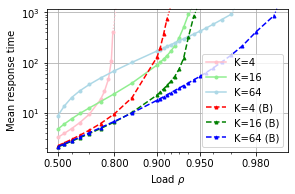

In [183]:
# MRT: EMW and EMW-Backfilling symmetric 

df = pd.read_excel(
    "/Users/heyuanyao/Desktop/cts MSJ/Simulation Data/Continuous MRJ.xlsx",
    sheet_name="TN(0.5,1)-EMW"
)

arrival_rate = df.iloc[:, 0].to_numpy()

fig, ax = plt.subplots(figsize=(6*0.7, 4*0.7))

Ks = ['4','16','64']

# colors = ['red','green','blue']
colors = ['pink','lightgreen','lightblue','red','green','blue',]

# plt.cm.tab20(np.linspace(0, 1, 3))

x = (2-arrival_rate)/2

y_all = [] 

for i, col in enumerate(df.columns[1:7]):
    y1 = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y1) & (arrival_rate > 0) & (y1 > 0) & (y1 <= 1000)
    y_valid1 = y1[mask]
    y_all.append(y_valid1)
y_all = np.concatenate(y_all)
y_upLimit = y_all.max()

for i, col in enumerate(df.columns[1:4]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) & (y <= 1000)
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    ax.plot(
        x_valid,
        y_valid,
        color=colors[i],
        marker='o',
        linewidth=1.5,
        markersize=3,
        # label=col
        label = 'K='+Ks[i]
    )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last * 0.95
    y_fake = y_upLimit * 1.3 

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
    )

    
for i, col in enumerate(df.columns[4:7]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) & (y <= 1000)
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    ax.plot(
        x_valid,
        y_valid,
        color=colors[i+3],
        marker='^',
        linewidth=1.5,
        linestyle = '--',
        markersize=3,
        # label=col
        label = 'K='+Ks[i]+' (B)'
    )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last * 0.95
    y_fake = y_upLimit * 1.3 

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i+3],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
    )
    
ax.set_ylim(y_all.min() * 0.8, y_upLimit * 1.3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()


ax.xaxis.set_major_locator(LogLocator(base=10,subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(FuncFormatter(one_minus_formatter))

ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel(r"Load $\rho$")
ax.set_ylabel("Mean response time")
ax.tick_params(axis='both')

ax.legend()
ax.grid(True, which="major")

plt.tight_layout()
plt.savefig("TN(0.5,1)-EMW-8.eps", format="eps", bbox_inches="tight",dpi=600)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


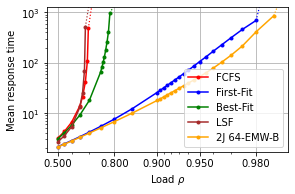

In [184]:
df = pd.read_excel(
    "/Users/heyuanyao/Desktop/cts MSJ/Simulation Data/Continuous MRJ.xlsx",
    sheet_name="TN(0.5,1)-Test"
)

arrival_rate = df.iloc[:, 0].to_numpy()

fig, ax = plt.subplots(figsize=(6*0.7, 4*0.7))
# colors = plt.cm.tab20(np.linspace(0, 1, 7))
colors = ['red','blue', 'green', 'brown','orange']

x = (2-arrival_rate)/2

y_all = [] 

for i, col in enumerate(df.columns[1:6]):
    y1 = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y1) & (arrival_rate > 0) & (y1 > 0) & (y1 <= 1000) 
    y_valid1 = y1[mask]
    y_all.append(y_valid1)
y_all = np.concatenate(y_all)
y_upLimit = y_all.max()

for i, col in enumerate(df.columns[1:6]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)& (y <= 1000) 
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    ax.plot(
        x_valid,
        y_valid,
        color=colors[i],
        marker='o',
        linewidth=1.5,
        markersize=3,
        label=col
    )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last * 0.95
    y_fake = y_upLimit * 1.3 

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
    )

ax.set_ylim(y_all.min() * 0.8, y_upLimit * 1.3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()

ax.xaxis.set_major_locator(LogLocator(base=10,subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(FuncFormatter(one_minus_formatter))
ax.xaxis.set_minor_formatter(NullFormatter())


ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel(r"Load $\rho$")
ax.set_ylabel("Mean response time")
ax.tick_params(axis='both')

ax.legend()
ax.grid(True, which="major")

plt.tight_layout()
plt.savefig("TN(0.5,1)-8.eps", format="eps", bbox_inches="tight",dpi=600)
plt.show()

## Borg Memory

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


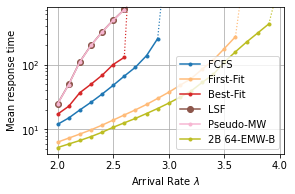

In [185]:
# Borg Memory MRT

df = pd.read_excel(
    "/Users/heyuanyao/Desktop/cts MSJ/Simulation Data/Continuous MRJ.xlsx",
    sheet_name="Borg_Memory_Rescaled"
)

arrival_rate = df.iloc[:, 0].to_numpy()

fig, ax = plt.subplots(figsize=(6*0.7, 4*0.7))
colors = plt.cm.tab20(np.linspace(0, 1, 7))

# x = (572.08-arrival_rate)/572.08
x = arrival_rate
y_all = [] 

for i, col in enumerate(df.columns[1:7]):
    y1 = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y1) & (y1 <= 1000)
    y_valid1 = y1[mask]
    y_all.append(y_valid1)
y_all = np.concatenate(y_all)
y_upLimit = y_all.max()

for i, col in enumerate(df.columns[1:7]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (y > 0) & (y <= 1000)
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    
    if i == 3:
        ax.plot(
        x_valid,
        y_valid,
        color=colors[i],
        marker='o',
        linewidth=1.5,
        markersize=6,
        label=col
        )
    else:   
        ax.plot(
            x_valid,
            y_valid,
            color=colors[i],
            marker='o',
            linewidth=1.5,
            markersize=3,
            label=col
        )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last * 1.01
    y_fake = y_upLimit * 1.1

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
   )

ax.set_ylim(y_all.min()*0.8, y_upLimit * 1.1)
# ax.set_xscale("log")
ax.set_yscale("log")
# ax.invert_xaxis()

# ax.xaxis.set_major_locator(LogLocator(base=10,subs=[1, 2, 5]))
# ax.xaxis.set_major_formatter(FuncFormatter(one_minus_formatter_Borg))
# ax.xaxis.set_minor_formatter(NullFormatter())


ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel(r"Arrival Rate $\lambda$")
ax.set_ylabel("Mean response time")
ax.tick_params(axis='both')

ax.legend()
ax.grid(True, which="major")

plt.tight_layout()
plt.savefig("Borg Memory-8.eps", format="eps", bbox_inches="tight",dpi=600)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


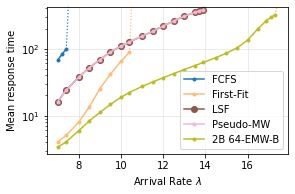

In [186]:
# Borg CPU MRT

df = pd.read_excel(
    "/Users/heyuanyao/Desktop/cts MSJ/Simulation Data/Continuous MRJ.xlsx",
    sheet_name="Borg_CPU_Rescaled"
)

arrival_rate = df.iloc[:, 0].to_numpy()
fig, ax = plt.subplots(figsize=(6*0.7, 4*0.7))

colors = plt.cm.tab20(np.linspace(0, 1, 7))

# x = (572.08-arrival_rate)/572.08
x = arrival_rate
y_all = [] 

for i, col in enumerate(df.columns[1:7]):
    y1 = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y1)
    y_valid1 = y1[mask]
    y_all.append(y_valid1)
y_all = np.concatenate(y_all)
y_upLimit = y_all.max()

for i, col in enumerate(df.columns[1:7]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (y > 0) 
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    if i == 3:
        ax.plot(
        x_valid,
        y_valid,
        color=colors[i],
        marker='o',
        linewidth=1.5,
        markersize=6,
        label=col
        )
    else:   
        ax.plot(
            x_valid,
            y_valid,
            color=colors[i],
            marker='o',
            linewidth=1.5,
            markersize=3,
            label=col
        )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last + 0.1
    y_fake = y_upLimit * 1.1

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
   )

ax.set_ylim(y_all.min()*0.8, y_upLimit * 1.1)
# ax.set_xscale("log")
ax.set_yscale("log")
# ax.invert_xaxis()

# ax.xaxis.set_major_locator(LogLocator(base=10,subs=[1, 2, 5]))
# ax.xaxis.set_major_formatter(FuncFormatter(one_minus_formatter_Borg))
# ax.xaxis.set_minor_formatter(NullFormatter())


ax.yaxis.set_major_locator(LogLocator(base=10))
# ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel(r"Arrival Rate $\lambda$")
ax.set_ylabel("Mean response time")
ax.tick_params(axis='both')

ax.legend()
ax.grid(True, which="major", alpha=0.3)

plt.tight_layout()
plt.savefig("Borg CPU-8.eps", format="eps", bbox_inches="tight",dpi=600)
plt.show()

## Decreasing

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

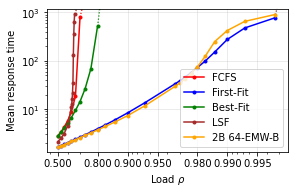

In [187]:
# MRT BLomax

df = pd.read_excel(
    "/Users/heyuanyao/Desktop/cts MSJ/Simulation Data/Continuous MRJ.xlsx",
    sheet_name="Blomax(2,1)"
)

arrival_rate = df.iloc[:, 0].to_numpy()

fig, ax = plt.subplots(figsize=(6*0.7, 4*0.7))

# colors = plt.cm.tab20(np.linspace(0, 1, 7))
colors = ['red','blue', 'green', 'brown','orange']

x = (3-arrival_rate)/3

y_all = [] 

for i, col in enumerate(df.columns[1:6]):
    y1 = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y1) & (arrival_rate > 0) & (y1 > 0) & (y1 <= 1000) 
    y_valid1 = y1[mask]
    y_all.append(y_valid1)
y_all = np.concatenate(y_all)
y_upLimit = y_all.max()

for i, col in enumerate(df.columns[1:6]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)& (y <= 1000) 
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    ax.plot(
        x_valid,
        y_valid,
        color=colors[i],
        marker='o',
        linewidth=1.5,
        markersize=3,
        label=col
    )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last * 0.95
    y_fake = y_upLimit * 1.3 

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
    )

ax.set_ylim(y_all.min() * 0.8, y_upLimit * 1.3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()

ax.xaxis.set_major_locator(LogLocator(base=10,subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(FuncFormatter(one_minus_formatter))
ax.xaxis.set_minor_formatter(NullFormatter())


ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel(r"Load $\rho$")
ax.set_ylabel("Mean response time")
ax.tick_params(axis='both')

ax.legend()
ax.grid(True, which="major", alpha=0.3)

plt.tight_layout()
plt.savefig("BLomax(2,1)-8.eps", format="eps", bbox_inches="tight",dpi=600)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

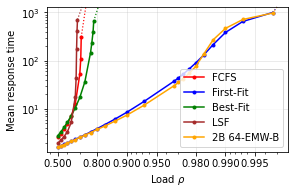

In [188]:
# MRT Triangular

df = pd.read_excel(
    "/Users/heyuanyao/Desktop/cts MSJ/Simulation Data/Continuous MRJ.xlsx",
    sheet_name="Tri(1)-test"
)

arrival_rate = df.iloc[:, 0].to_numpy()

fig, ax = plt.subplots(figsize=(6*0.7, 4*0.7))

# colors = plt.cm.tab20(np.linspace(0, 1, 7))
colors = ['red','blue', 'green', 'brown','orange']

x = (3-arrival_rate)/3

y_all = [] 

for i, col in enumerate(df.columns[1:6]):
    y1 = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y1) & (arrival_rate > 0) & (y1 > 0) & (y1 <= 1000) 
    y_valid1 = y1[mask]
    y_all.append(y_valid1)
y_all = np.concatenate(y_all)
y_upLimit = y_all.max()

for i, col in enumerate(df.columns[1:6]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)& (y <= 1000) 
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    ax.plot(
        x_valid,
        y_valid,
        color=colors[i],
        marker='o',
        linewidth=1.5,
        markersize=3,
        label=col
    )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last * 0.9
    y_fake = y_upLimit * 1.3 

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
    )

ax.set_ylim(y_all.min() * 0.8, y_upLimit * 1.3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()

ax.xaxis.set_major_locator(LogLocator(base=10,subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(FuncFormatter(one_minus_formatter))
ax.xaxis.set_minor_formatter(NullFormatter())


ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel(r"Load $\rho$")
ax.set_ylabel("Mean response time")
ax.tick_params(axis='both')

ax.legend()
ax.grid(True, which="major", alpha=0.3)

plt.tight_layout()
plt.savefig("Tri(1)-8.eps", format="eps", bbox_inches="tight",dpi=600)
plt.show()

## Summetric Triangular

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


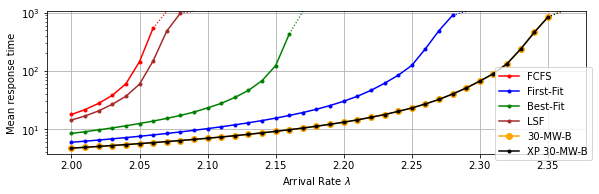

In [189]:
# IsoTri(1/4, 1/2) MRT

df = pd.read_excel(
    "/Users/heyuanyao/Desktop/cts MSJ/Simulation Data/Continuous MRJ.xlsx",
    sheet_name="IsoTri"
)

arrival_rate = df.iloc[:, 0].to_numpy()

fig, ax = plt.subplots(figsize=(12*0.7, 4*0.7))

# colors = plt.cm.tab20(np.linspace(0, 1, 6))
colors = ['red','blue', 'green', 'brown','orange','black']

# x = (572.08-arrival_rate)/572.08
x = arrival_rate
y_all = [] 

for i, col in enumerate(df.columns[1:7]):
    y1 = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y1) & (y1 <= 1000)
    y_valid1 = y1[mask]
    y_all.append(y_valid1)
y_all = np.concatenate(y_all)
y_upLimit = y_all.max()

for i, col in enumerate(df.columns[1:7]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (y > 0) & (y <= 1000)
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]
    
    if colors[i] == 'orange' :
        ax.plot(
        x_valid,
        y_valid,
        color=colors[i],
        marker='o',
        linewidth=1.5,
        markersize=6,
        label=col
        )
    else:
        ax.plot(
            x_valid,
            y_valid,
            color=colors[i],
            marker='o',
            linewidth=1.5,
            markersize=3,
            label=col
        )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last +0.01
    y_fake = 1000 * 1.05

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
   )

ax.set_ylim(y_all.min() * 0.8, 1000 * 1.05)
# ax.set_xscale("log")
ax.set_yscale("log")
# ax.invert_xaxis()

# ax.xaxis.set_major_locator(LogLocator(base=10,subs=[1, 2, 5]))
# ax.xaxis.set_major_formatter(FuncFormatter(one_minus_formatter_Borg))
# ax.xaxis.set_minor_formatter(NullFormatter())


ax.yaxis.set_major_locator(LogLocator(base=10))
# ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel(r"Arrival Rate $\lambda$")
ax.set_ylabel("Mean response time")
ax.tick_params(axis='both')

# ax.legend()
ax.legend(loc='center right', bbox_to_anchor=(1.02, 0.28))
ax.grid(True, which="major")

plt.tight_layout()
plt.savefig("IsoTri-8.eps", format="eps", bbox_inches="tight",dpi=600)
plt.show()

## Comparison of Efficient & Standard


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


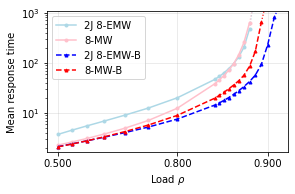

In [190]:
df = pd.read_excel(
    "/Users/heyuanyao/Desktop/cts MSJ/Simulation Data/Continuous MRJ.xlsx",
    sheet_name="8-Comp"
)

arrival_rate = df.iloc[:, 0].to_numpy()

fig, ax = plt.subplots(figsize=(6*0.7, 4*0.7))

colors = ['lightblue','pink','blue','red']
# plt.cm.tab20(np.linspace(0, 1, 4))

x = (2-arrival_rate)/2

y_all = [] 

for i, col in enumerate(df.columns[1:5]):
    y1 = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y1) & (arrival_rate > 0) & (y1 > 0)
    y_valid1 = y1[mask]
    y_all.append(y_valid1)
y_all = np.concatenate(y_all)
y_upLimit = y_all.max()


for i, col in enumerate(df.columns[1:3]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) 
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    ax.plot(
        x_valid,
        y_valid,
        color=colors[i],
        marker='o',
        linewidth=1.5,
        markersize=3,
        label=col
    )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last * 0.98
    y_fake = y_upLimit * 1.3 

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
    )

    
for i, col in enumerate(df.columns[3:5]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) & (y <= 1000)
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    ax.plot(
        x_valid,
        y_valid,
        color=colors[i+2],
        marker='^',
        linewidth=1.5,
        linestyle='--',
        markersize=3,
        label=col
    )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last * 0.98
    y_fake = y_upLimit * 1.3 

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i+2],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
    )
    
ax.set_ylim(y_all.min() * 0.8, y_upLimit * 1.3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()


ax.xaxis.set_major_locator(LogLocator(base=10,subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(FuncFormatter(one_minus_formatter))

ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel(r"Load $\rho$")
ax.set_ylabel("Mean response time")
ax.tick_params(axis='both')

ax.xaxis.set_minor_locator(NullLocator())
ax.xaxis.set_minor_formatter(NullFormatter())

ax.legend()
ax.grid(True, which="major", alpha=0.3)

plt.tight_layout()
plt.savefig("8-Comp-MRT-8.eps", format="eps", bbox_inches="tight",dpi=600)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


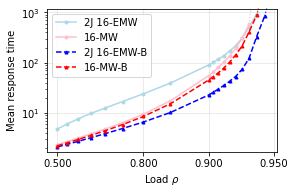

In [191]:
df = pd.read_excel(
    "/Users/heyuanyao/Desktop/cts MSJ/Simulation Data/Continuous MRJ.xlsx",
    sheet_name="16-Comp"
)

arrival_rate = df.iloc[:, 0].to_numpy()

fig, ax = plt.subplots(figsize=(6*0.7, 4*0.7))

colors = ['lightblue','pink','blue','red']

# colors = plt.cm.tab20(np.linspace(0, 1, 4))

x = (2-arrival_rate)/2

y_all = [] 

for i, col in enumerate(df.columns[1:5]):
    y1 = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y1) & (arrival_rate > 0) & (y1 > 0)
    y_valid1 = y1[mask]
    y_all.append(y_valid1)
y_all = np.concatenate(y_all)
y_upLimit = y_all.max()


for i, col in enumerate(df.columns[1:3]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) 
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    ax.plot(
        x_valid,
        y_valid,
        color=colors[i],
        marker='o',
        linewidth=1.5,
        markersize=3,
        label=col
    )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last * 0.98
    y_fake = y_upLimit * 1.3 

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
    )

    
for i, col in enumerate(df.columns[3:5]):
    y = pd.to_numeric(df[col]).to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) & (y <= 1000)
    if not np.any(mask):
        continue

    x_valid = x[mask]
    y_valid = y[mask]

    ax.plot(
        x_valid,
        y_valid,
        color=colors[i+2],
        marker='^',
        linewidth=1.5,
        markersize=3,
        linestyle='--',
        label=col
    )

    x_last = x_valid[-1]
    y_last = y_valid[-1]

    x_fake = x_last * 0.98
    y_fake = y_upLimit * 1.3 

    ax.plot(
        [x_last, x_fake],
        [y_last, y_fake],
        linestyle=':',
        color=colors[i+2],
        linewidth=1.2,
        clip_on=False        
    )

    ax.plot(
        x_fake,
        y_fake,
        clip_on=False          
    )
    
ax.set_ylim(y_all.min() * 0.8, y_upLimit * 1.3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()


ax.xaxis.set_major_locator(LogLocator(base=10,subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(FuncFormatter(one_minus_formatter))

ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel(r"Load $\rho$")
ax.set_ylabel("Mean response time")
ax.tick_params(axis='both')

ax.xaxis.set_minor_locator(NullLocator())
ax.xaxis.set_minor_formatter(NullFormatter())

ax.legend()
ax.grid(True, which="major", alpha=0.3)

plt.tight_layout()
plt.savefig("16-Comp-MRT-8.eps", format="eps", bbox_inches="tight",dpi=600)
plt.show()